In [3]:
import numpy as np
def oracle_reward(self,x,u,con):

    R = 0.01
    SP = self.SP
    if not hasattr(self, 'u_prev'):
        self.u_prev = u

    CV = (x[2]*x[0]/(x[1]**2) - 1)**0.5
    ln = x[1]/x[0]

    o_space_low = self.env_params["o_space"]["low"][[5,6]] 
    o_space_high = self.env_params["o_space"]["high"][[5,6]] 

    CV_normalized = (CV - o_space_low[0]) / (o_space_high[0] - o_space_low[0])
    Ln_normalized = (ln - o_space_low[1]) / (o_space_high[1] - o_space_low[1])
    SP_CV = (SP['CV'][self.t] - o_space_low[0]) / (o_space_high[0] - o_space_low[0])
    SP_Ln = (SP['Ln'][self.t] - o_space_low[1]) / (o_space_high[1] - o_space_low[1])

    r = -1*((SP_CV - CV_normalized)**2 + (SP_Ln - Ln_normalized)**2)


    u_normalized = (u - self.env_params["a_space"]["low"]) / (
        self.env_params["a_space"]["high"] - self.env_params["a_space"]["low"]
    )
    u_prev_norm =  (self.u_prev - self.env_params["a_space"]["low"]) / (
        self.env_params["a_space"]["high"] - self.env_params["a_space"]["low"]
    )

    r -= np.sum(R * (u_normalized-u_prev_norm)**2)
    self.u_prev = u

    return r

In [1]:
import numpy as np
from pcgym import make_env

# =====================================================================
# UPDATED TIMELINE PARAMETERS
# =====================================================================
T = 30.0       # Total time horizon = 30 min
nsteps = 30    # N = 30 discrete time steps (resulting in dt = 1.0 min)

# =====================================================================
# TARGET SETPOINTS (SP) FROM TABLE 2
# =====================================================================
SP = {
    'CV': [1.00 for _ in range(nsteps)],
    'Ln': [15.00 for _ in range(nsteps)]
}

# =====================================================================
# UPDATED ACTION SPACE (Incremental control bounds)
# =====================================================================
action_space = {
    'low': np.array([-1.0]),   # Minimum delta T step allowed per minute
    'high': np.array([1.0])    # Maximum delta T step allowed per minute
}

# =====================================================================
# OBSERVATION SPACE (State Bounds from Table 2 + Setpoints)
# =====================================================================
# Order: [mu0, mu1, mu2, mu3, C, CV, Ln, CV_SP, Ln_SP]
observation_space = {
    'low' : np.array([0.0, 0.0, 0.0, 0.0, 0.00, 0.00, 0.00, 0.00, 0.00]),
    'high' : np.array([1.0e20, 1.0e20, 1.0e20, 1.0e20, 0.50, 2.00, 20.00, 2.00, 20.00])  
}

# =====================================================================
# ENVIRONMENT PARAMETERS SETUP
# =====================================================================
env_params = {
    'N': nsteps, 
    'tsim': T, 
    'SP': SP, 
    'o_space': observation_space, 
    'a_space': action_space,
    
    # Initial conditions (x0) including the initial setpoints
    'x0': np.array([1.50e3, 2.30e4, 1.80e6, 2.50e8, 0.16, 1.00, 15.00, 1.00, 15.00]),
    
    'r_scale': {
        'CV': 1e1,
        'Ln': 1e0
    },
    
    'model': 'crystallization', 
    
    'normalise_a': True, 
    'normalise_o': True, 
    'noise': True, 
    'integration_method': 'jax', 
    'noise_percentage': 0.01, 
}
# env_params['custom_reward'] = oracle_reward
# Initialize Environment
env = make_env(env_params)
obs, info = env.reset()

print("Environment successfully setted!")

Environment successfully setted!


/Users/phattharapongduangkham/Documents/crystallization-partial-drl-ml/.venv/lib/python3.12/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/phattharapongduangkham/Documents/crystallization-partial-drl-ml/.venv/lib/python3.12/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


In [2]:
from stable_baselines3 import PPO

nsteps_learning = 30000
PPO_policy = PPO('MlpPolicy', env, verbose=1).learn(nsteps_learning)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/Users/phattharapongduangkham/Documents/crystallization-partial-drl-ml/.venv/lib/python3.12/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/phattharapongduangkham/Documents/crystallization-partial-drl-ml/.venv/lib/python3.12/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


----------------------------------
| rollout/           |           |
|    ep_len_mean     | 29        |
|    ep_rew_mean     | -3.58e+03 |
| time/              |           |
|    fps             | 85        |
|    iterations      | 1         |
|    time_elapsed    | 23        |
|    total_timesteps | 2048      |
----------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 29          |
|    ep_rew_mean          | -3.59e+03   |
| time/                   |             |
|    fps                  | 87          |
|    iterations           | 2           |
|    time_elapsed         | 46          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.006191659 |
|    clip_fraction        | 0.0429      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.42       |
|    explained_variance   | 0.000228    |
|    learning_rate  

/Users/phattharapongduangkham/Documents/crystallization-partial-drl-ml/.venv/lib/python3.12/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/phattharapongduangkham/Documents/crystallization-partial-drl-ml/.venv/lib/python3.12/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


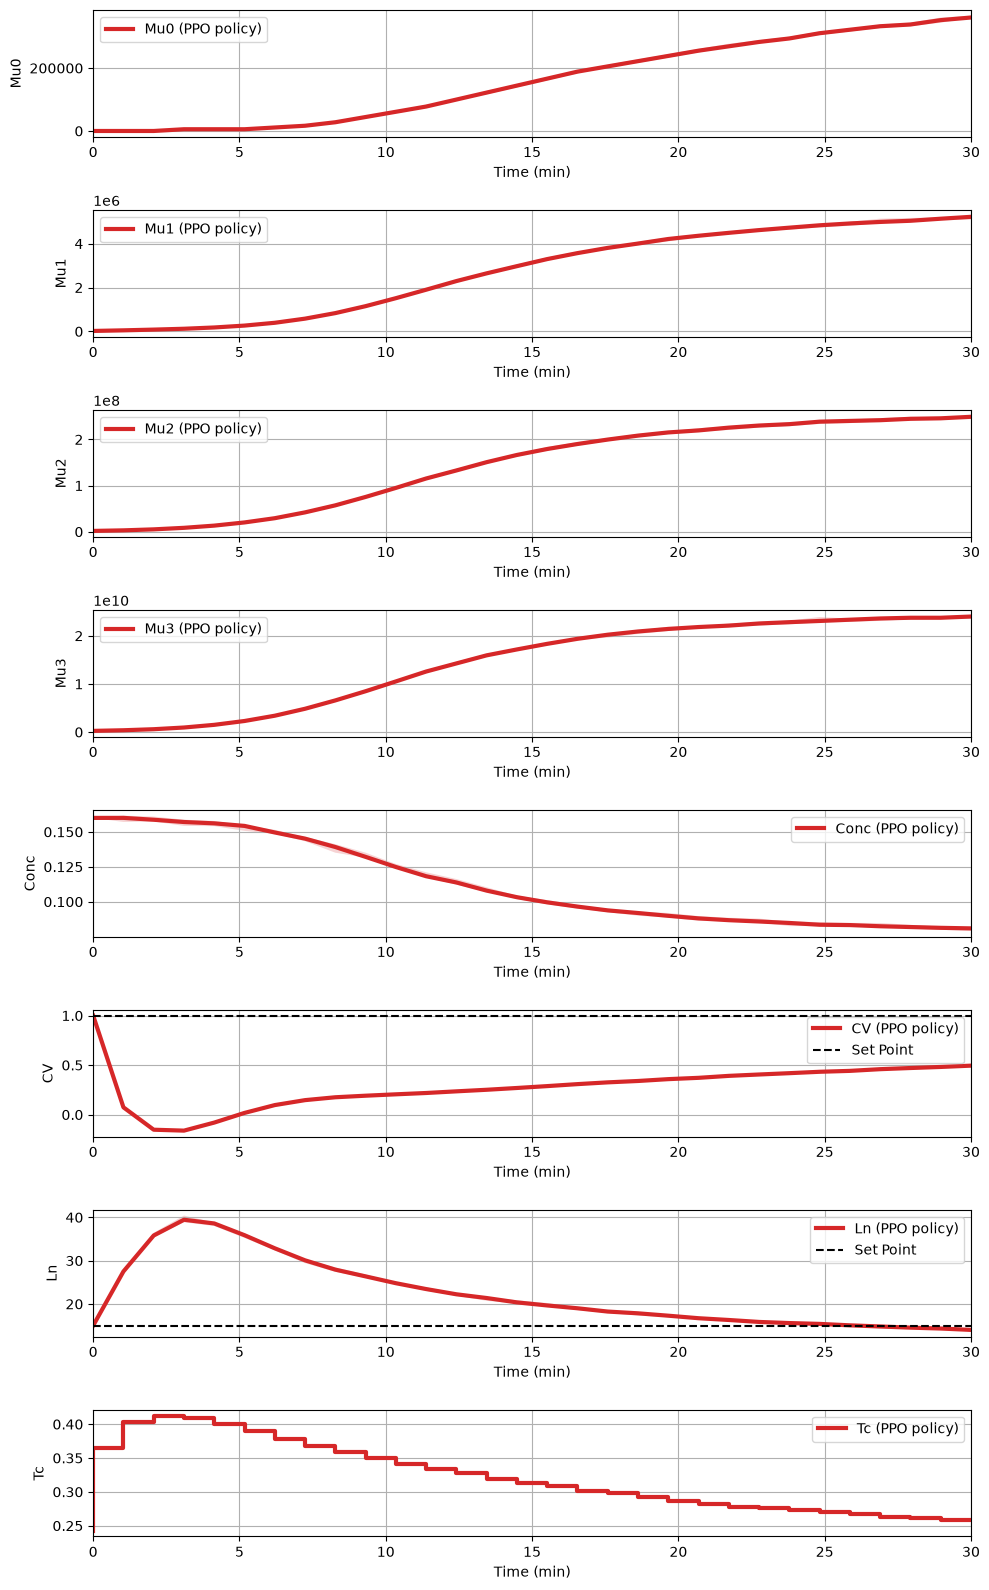

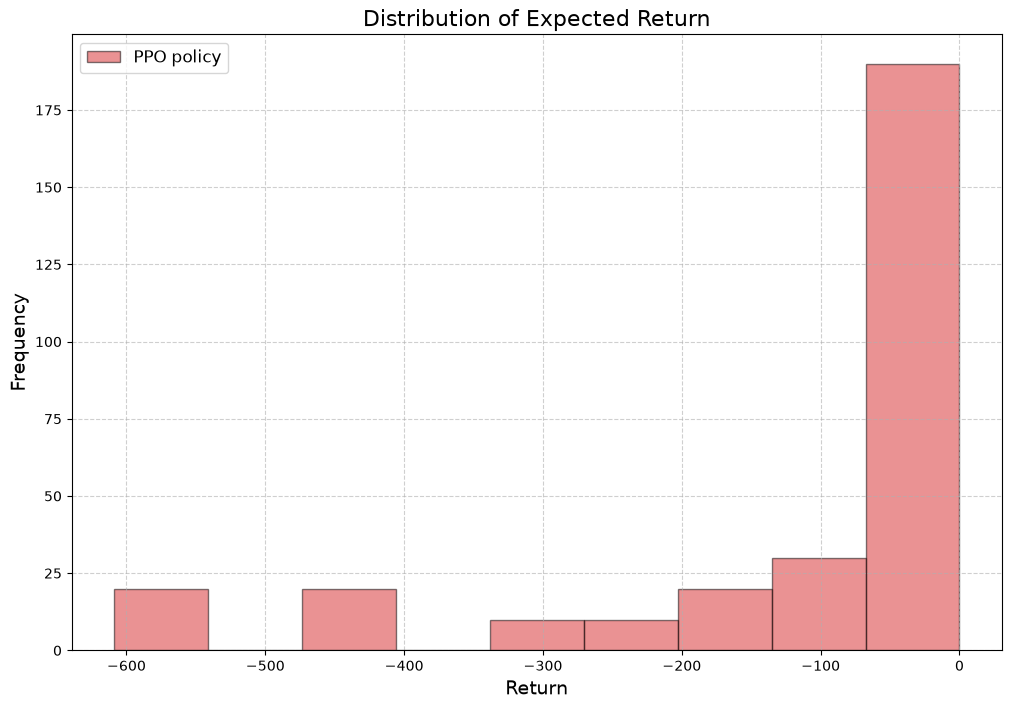

Your final score is: -117.76 (larger the better).


In [3]:
evaluator, data = env.plot_rollout({'PPO policy':PPO_policy}, reps = 10, oracle = False, dist_reward=True) #, MPC_params={'N':10,'R':0.1}) # Rollout your policy
res = data['PPO policy']['r'].mean()
print(f"Your final score is: {res:.2f} (larger the better).")

In [ ]:
PPO_policy.save(f'ppo-default-{nsteps_learning}')

[I 2026-06-26 08:19:58,233] A new study created in memory with name: PPO_Trading_Optimization
/var/folders/hg/d439q2312vx8w7gk1809hs7c0000gn/T/ipykernel_70093/1952345225.py:25: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-3)
/var/folders/hg/d439q2312vx8w7gk1809hs7c0000gn/T/ipykernel_70093/1952345225.py:26: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  gamma = trial.suggest_uniform('gamma', 0.9, 0.9999)


Trial 0: lr=0.000068, gamma=0.9720
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 29        |
|    ep_rew_mean     | -3.67e+03 |
| time/              |           |
|    fps             | 44        |
|    iterations      | 1         |
|    time_elapsed    | 45        |
|    total_timesteps | 2048      |
----------------------------------
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 29            |
|    ep_rew_mean          | -3.63e+03     |
| time/                   |               |
|    fps                  | 43            |
|    iterations           | 2             |
|    time_elapsed         | 94            |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 1.9103172e-06 |
|    clip_fraction        | 0        

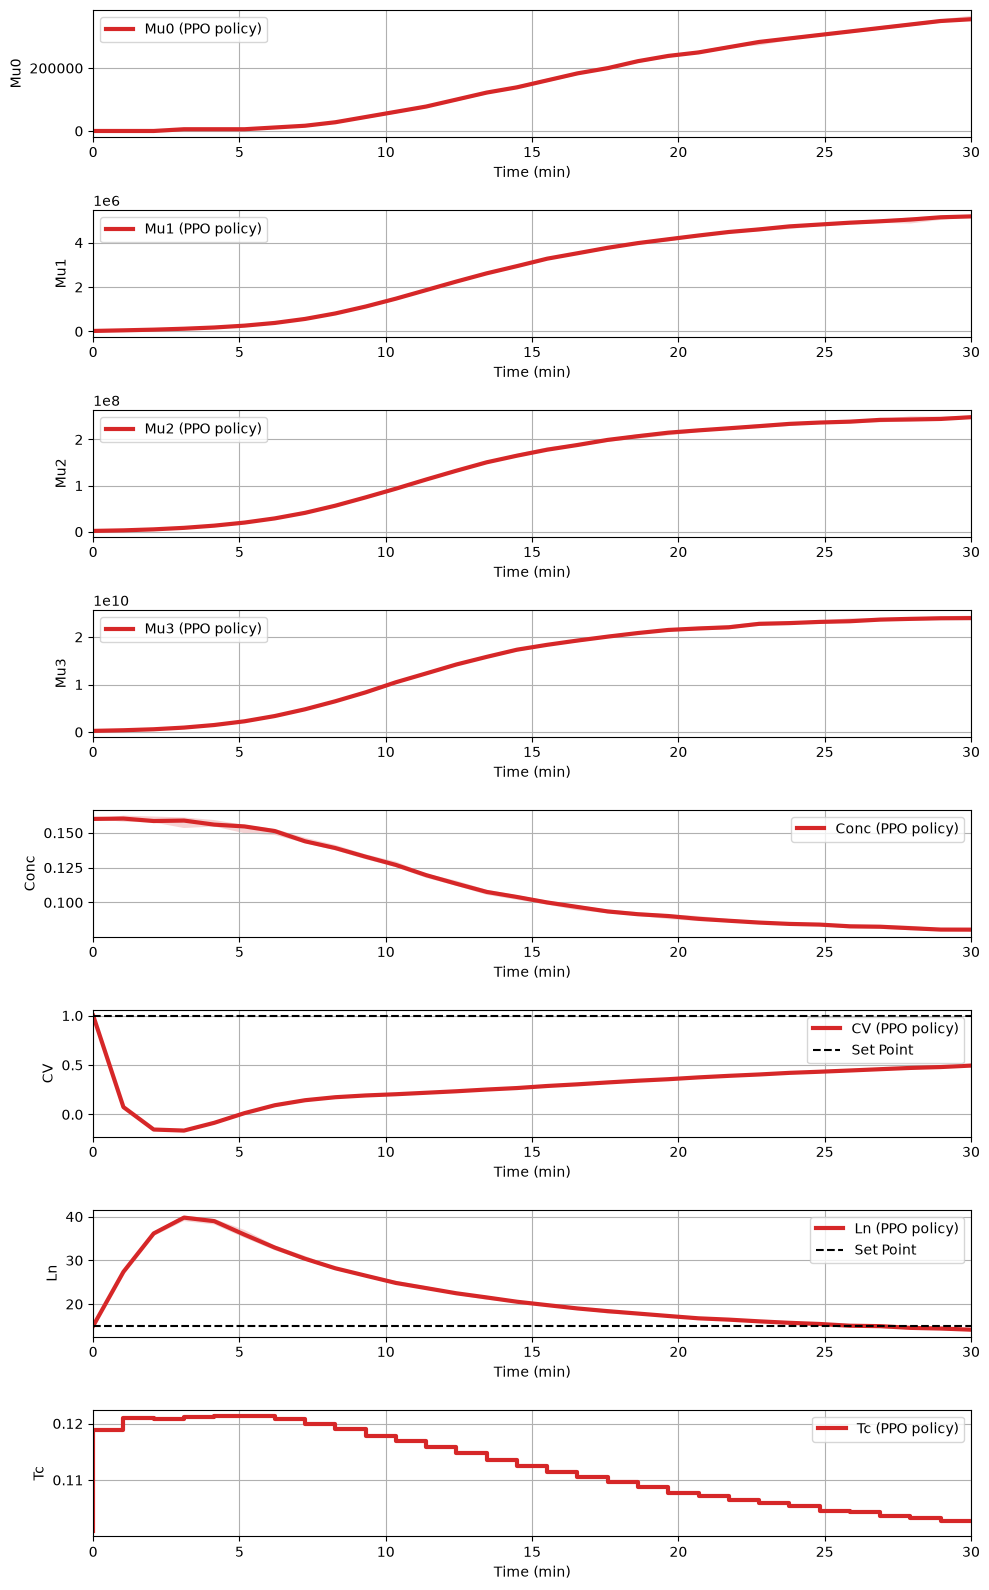

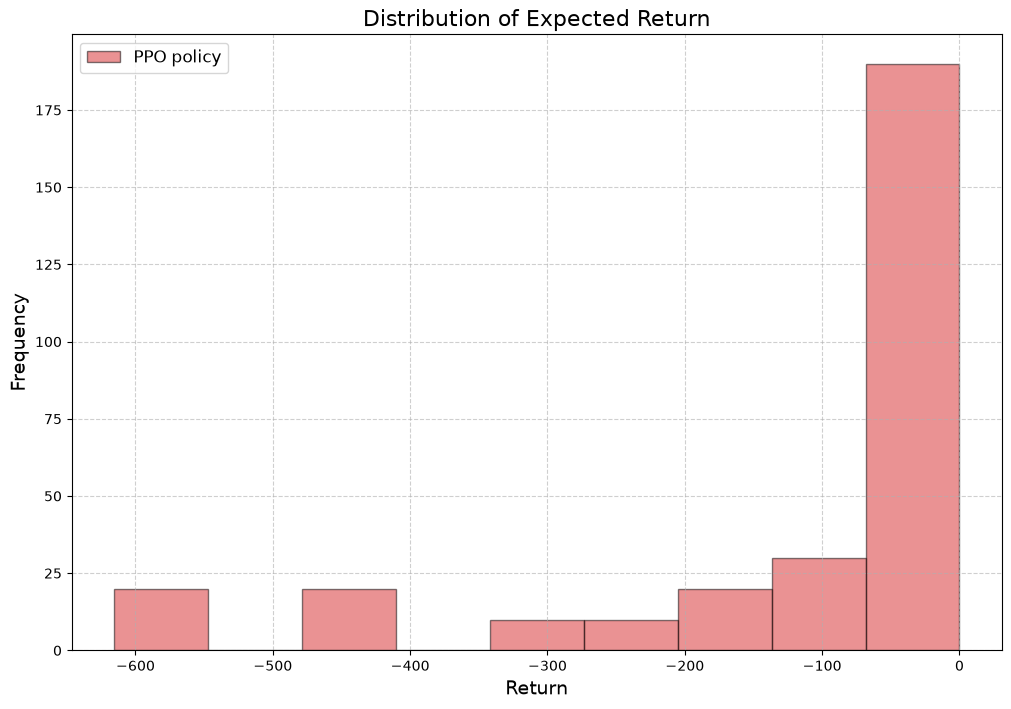

[I 2026-06-26 08:45:44,876] Trial 0 finished with value: -120.12834708108167 and parameters: {'learning_rate': 6.82407842709883e-05, 'gamma': 0.9719604168948716}. Best is trial 0 with value: -120.12834708108167.


Trial 1: lr=0.000010, gamma=0.9302
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 29        |
|    ep_rew_mean     | -3.67e+03 |
| time/              |           |
|    fps             | 16        |
|    iterations      | 1         |
|    time_elapsed    | 124       |
|    total_timesteps | 2048      |
----------------------------------
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 29            |
|    ep_rew_mean          | -3.63e+03     |
| time/                   |               |
|    fps                  | 10            |
|    iterations           | 2             |
|    time_elapsed         | 383           |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 1.5008845e-07 |
|    clip_fraction        | 0        

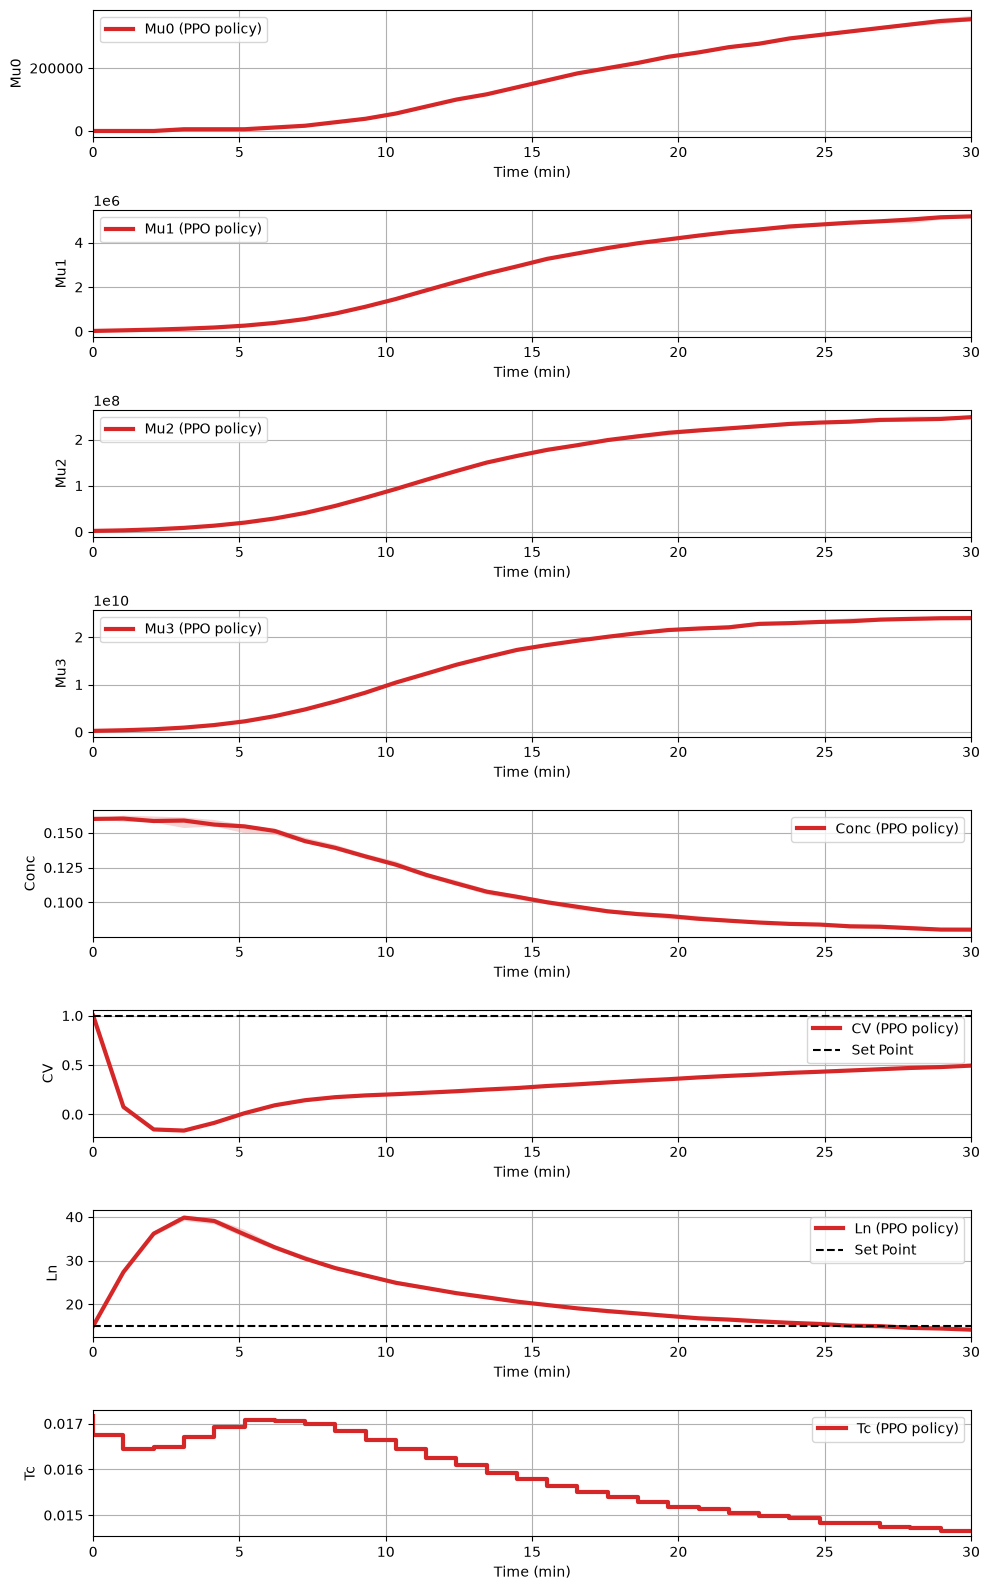

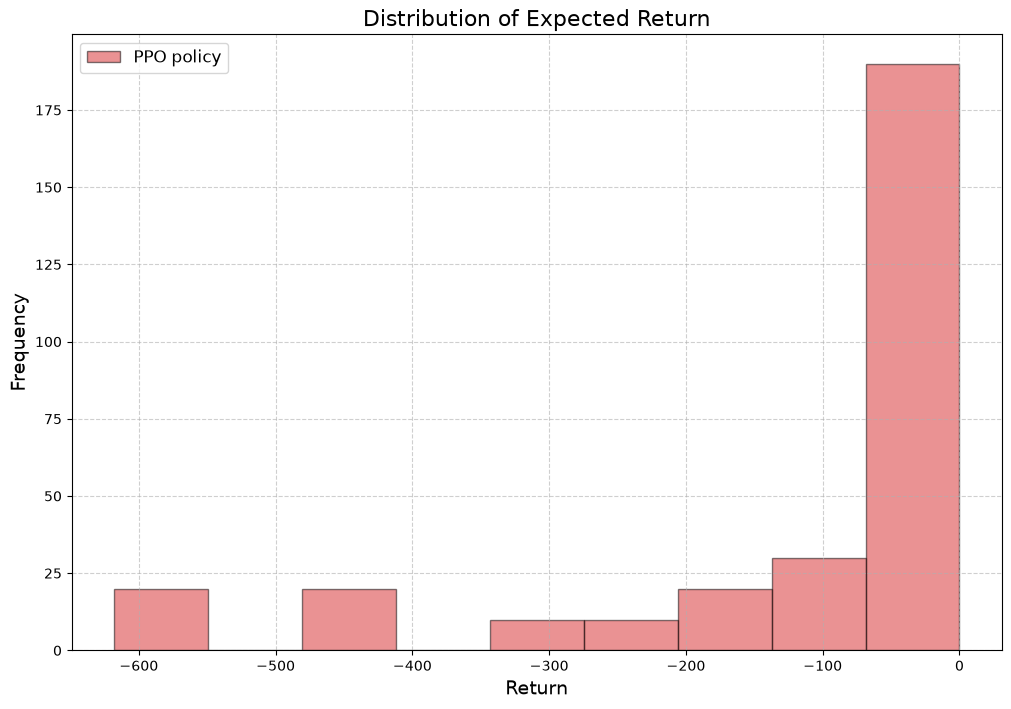

[I 2026-06-26 09:26:06,076] Trial 1 finished with value: -121.07809035122438 and parameters: {'learning_rate': 1.0005268542378301e-05, 'gamma': 0.9302030240059208}. Best is trial 0 with value: -120.12834708108167.


Trial 2: lr=0.000020, gamma=0.9092
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 29        |
|    ep_rew_mean     | -3.67e+03 |
| time/              |           |
|    fps             | 13        |
|    iterations      | 1         |
|    time_elapsed    | 153       |
|    total_timesteps | 2048      |
----------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 29           |
|    ep_rew_mean          | -3.63e+03    |
| time/                   |              |
|    fps                  | 5            |
|    iterations           | 2            |
|    time_elapsed         | 750          |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 9.856012e-07 |
|    clip_fraction        | 0            |
|    

[W 2026-06-26 10:02:55,991] Trial 2 failed with parameters: {'learning_rate': 1.9656753051200302e-05, 'gamma': 0.9092246256174029} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Users/phattharapongduangkham/Documents/pc-gym/.venv/lib/python3.12/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/var/folders/hg/d439q2312vx8w7gk1809hs7c0000gn/T/ipykernel_70093/1952345225.py", line 64, in <lambda>
    study.optimize(lambda n_trials: objective(n_trials, PPO), n_trials=N_TRIALS)
                                    ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/hg/d439q2312vx8w7gk1809hs7c0000gn/T/ipykernel_70093/1952345225.py", line 44, in objective
    model.learn(total_timesteps=30000)
  File "/Users/phattharapongduangkham/Documents/pc-gym/.venv/lib/python3.12/site-packages/stable_baselines3/ppo/ppo.py", line 311, in learn
    return super().learn(
   

KeyboardInterrupt: 

In [7]:
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from optuna.visualization import plot_optimization_history, plot_param_importances
from stable_baselines3 import PPO, A2C, DDPG
import pandas as pd
from tqdm import tqdm

def objective(trial, model_name):
    """
    Optuna objective function to optimize stable_baselines3 models(like PPO, A2C, DDPG) hyperparameters.
    
    Args:
        trial: Optuna trial object for parameter sampling
        
    Returns:
        float: Result value (objective is to maximize)

    1. Loop through all models (PPO, A2C, ...)
    2. Adding net_arch and activation_fn optimization
    3. Summarize into dataframe table

    """
    # Sample hyperparameters from defined ranges
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-3)
    gamma = trial.suggest_uniform('gamma', 0.9, 0.9999)
    # clip_range = trial.suggest_uniform('clip_range', 0.1, 0.3)
    
    print(f"Trial {trial.number}: lr={learning_rate:.6f}, gamma={gamma:.4f}") # , clip={clip_range:.3f}")
    
    # Create fresh environment for this trial
    env_trial = make_env(env_params)
    
    # Initialize and train PPO model
    model = model_name("MlpPolicy", 
                env_trial, 
                verbose=1,
                learning_rate=learning_rate,
                gamma=gamma,
                # clip_range=clip_range,
                seed=RANDOM_SEED)
    
    # Train the model
    model.learn(total_timesteps=30000)
    
    # Execute trading simulation
    observation, info = env_trial.reset(seed=RANDOM_SEED)
    
    str_model_name = str(model_name).split('.')[-1][0:-2]
    evaluator, data = env_trial.plot_rollout({f'{str_model_name} policy':model}, reps = 10, oracle = False, dist_reward=True) # Rollout your policy
    res = data[f'{str_model_name} policy']['r'].mean() 
    
    return res


RANDOM_SEED = 1

study = optuna.create_study(direction='maximize', 
                           study_name='PPO_Trading_Optimization',
                           sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))

# Run optimization with specified number of trials
N_TRIALS = 5
study.optimize(lambda n_trials: objective(n_trials, PPO), n_trials=N_TRIALS)

# Display results
print(f"\nOptimization completed after {N_TRIALS} trials!")
print(f"Best trial: {study.best_trial.number}")
print(f"Best value: ${study.best_value:,.2f}")
print(f"Best paramete=   rs: {study.best_trial.params}")

# Store best parameters for later use
best_params = study.best_trial.params
print(f"\nOptimal hyperparameters saved for model training.")

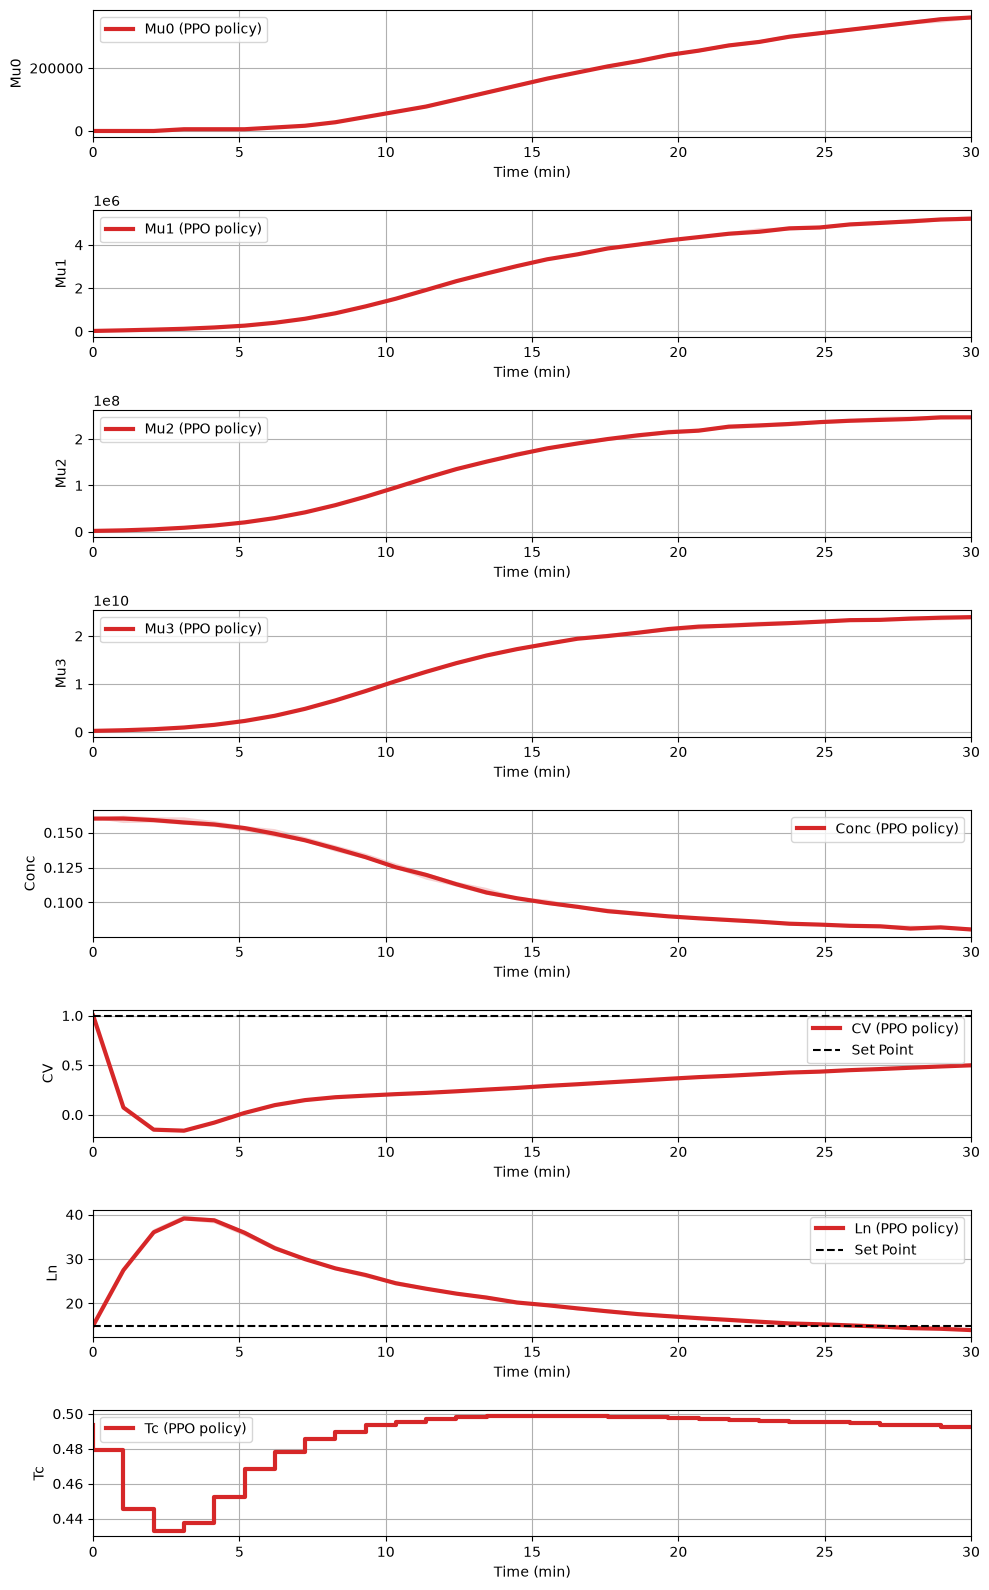

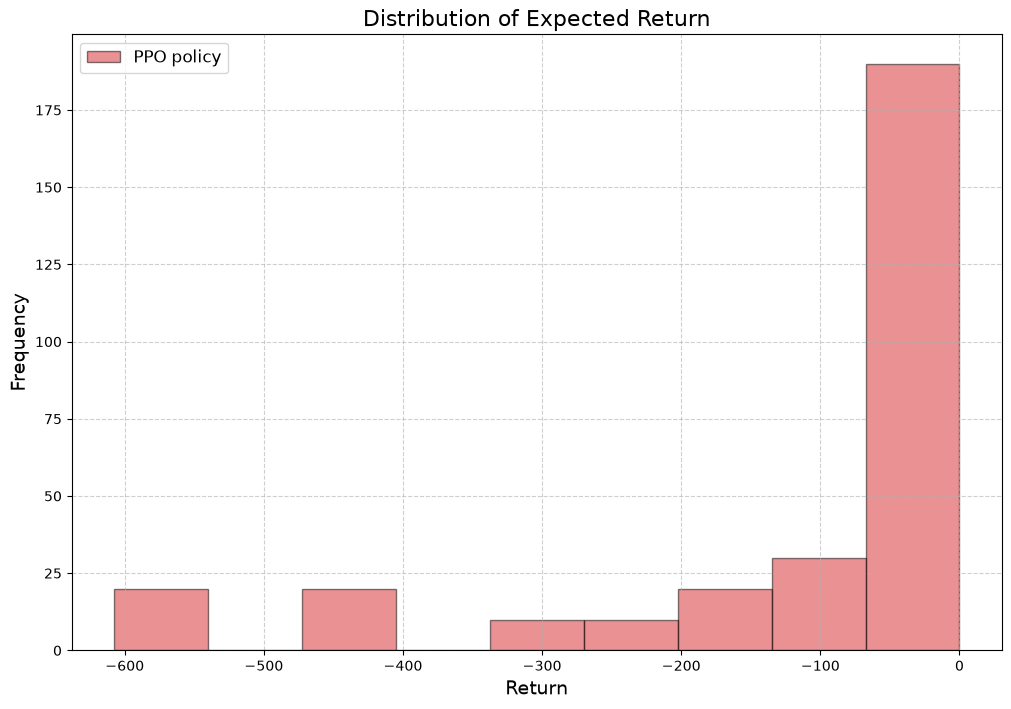

Your final score is: -117.00 (larger the better).


In [3]:
evaluator, data = env.plot_rollout({'PPO policy':PPO_policy}, reps = 10, oracle = False, dist_reward=True) #, MPC_params={'N':10,'R':0.1}) # Rollout your policy
res = data['PPO policy']['r'].mean()
print(f"Your final score is: {res:.2f} (larger the better).")